In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import contextily as ctx
from shapely.geometry import Point, LineString
import geopandas as gpd
from sklearn.cluster import DBSCAN
import networkx as nx

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

gdf = gpd.read_file("wynik.geojson")

gdf['Czas wyjazdu ZRM'] = pd.to_datetime(gdf['Czas wyjazdu ZRM'])
gdf['Czas powrotu ZRM'] = pd.to_datetime(gdf['Czas powrotu ZRM'])

gdf['Czas trwania (min)'] = (gdf['Czas powrotu ZRM'] - gdf['Czas wyjazdu ZRM']).dt.total_seconds() / 60

gdf['Godzina wyjazdu'] = gdf['Czas wyjazdu ZRM'].dt.hour
gdf['Dzień tygodnia'] = gdf['Czas wyjazdu ZRM'].dt.dayofweek
gdf['Miesiąc'] = gdf['Czas wyjazdu ZRM'].dt.month
gdf['Dzień miesiąca'] = gdf['Czas wyjazdu ZRM'].dt.day

day_names = {0: 'Poniedziałek', 1: 'Wtorek', 2: 'Środa', 3: 'Czwartek', 
             4: 'Piątek', 5: 'Sobota', 6: 'Niedziela'}
gdf['Dzień tygodnia nazwa'] = gdf['Dzień tygodnia'].map(day_names)

month_names = {1: 'Styczeń', 2: 'Luty', 3: 'Marzec', 4: 'Kwiecień', 
               5: 'Maj', 6: 'Czerwiec', 7: 'Lipiec', 8: 'Sierpień',
               9: 'Wrzesień', 10: 'Październik', 11: 'Listopad', 12: 'Grudzień'}
gdf['Miesiąc nazwa'] = gdf['Miesiąc'].map(month_names)

gdf['Długość trasy (km)'] = gdf.geometry.length * 111

/tmp/ipykernel_92599/4051460211.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['Długość trasy (km)'] = gdf.geometry.length * 111


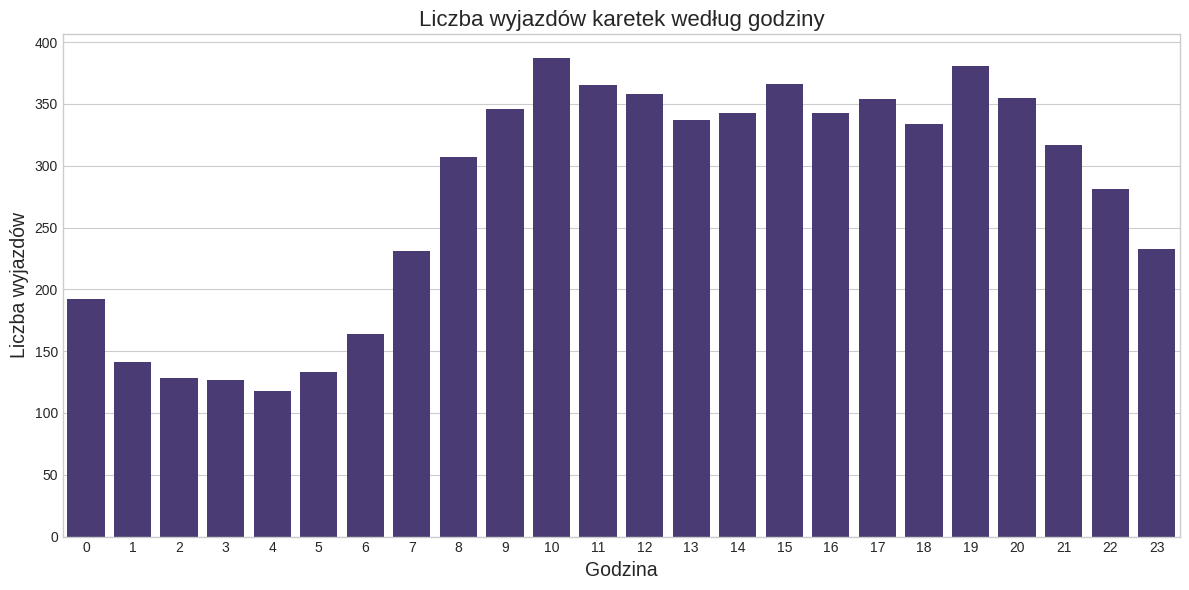

In [3]:
plt.figure(figsize=(12, 6))
hour_counts = gdf['Godzina wyjazdu'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Liczba wyjazdów karetek według godziny', fontsize=16)
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.xticks(np.arange(0, 24))
plt.tight_layout()
plt.show()

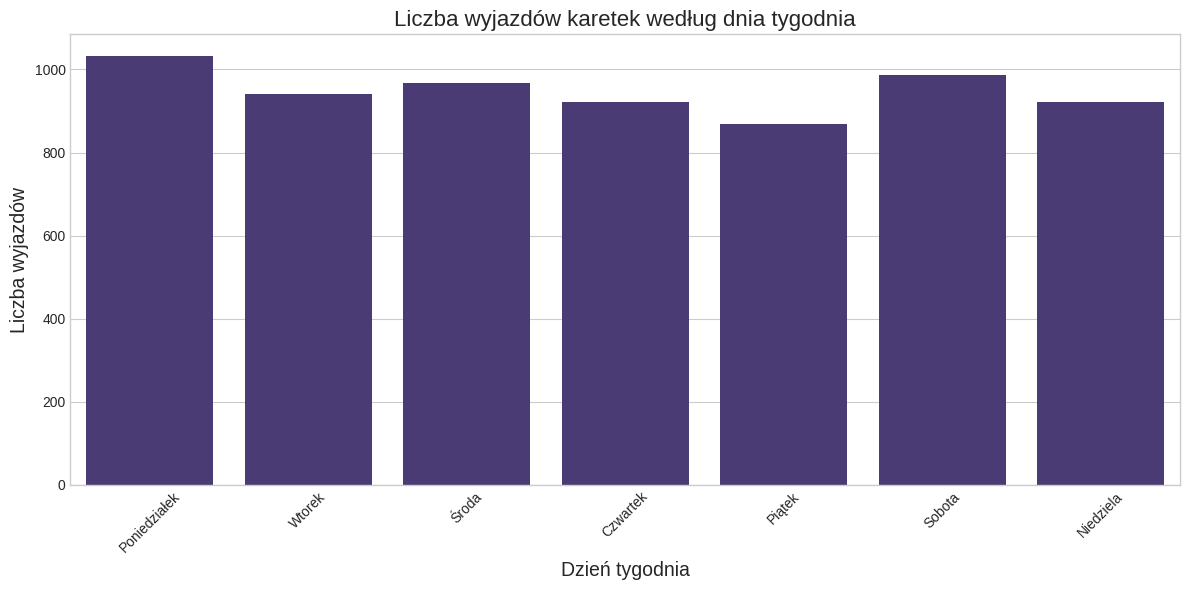

In [4]:
plt.figure(figsize=(12, 6))
day_counts = gdf['Dzień tygodnia nazwa'].value_counts().reindex(
    ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek', 'Sobota', 'Niedziela'])
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title('Liczba wyjazdów karetek według dnia tygodnia', fontsize=16)
plt.xlabel('Dzień tygodnia', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

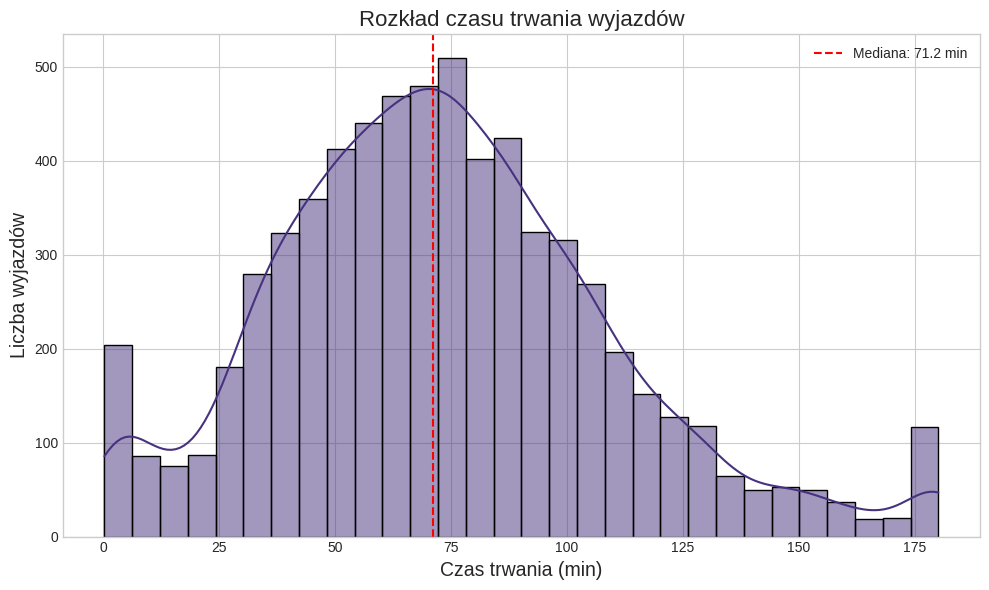

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(gdf['Czas trwania (min)'].clip(upper=180), bins=30, kde=True)
plt.axvline(gdf['Czas trwania (min)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf["Czas trwania (min)"].median():.1f} min')
plt.title('Rozkład czasu trwania wyjazdów', fontsize=16)
plt.xlabel('Czas trwania (min)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

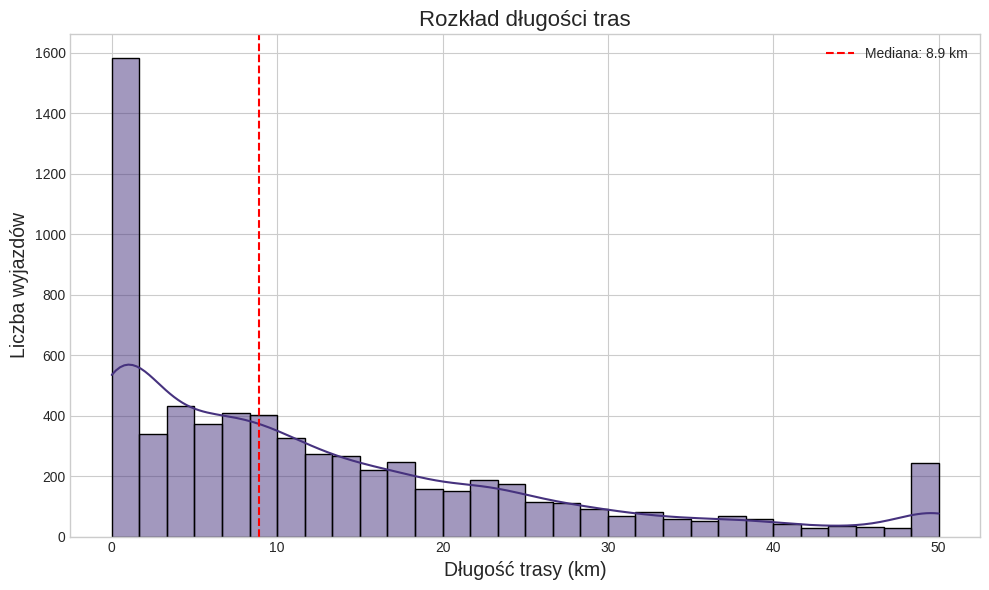

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(gdf['Długość trasy (km)'].clip(upper=50), bins=30, kde=True)
plt.axvline(gdf['Długość trasy (km)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf["Długość trasy (km)"].median():.1f} km')
plt.title('Rozkład długości tras', fontsize=16)
plt.xlabel('Długość trasy (km)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

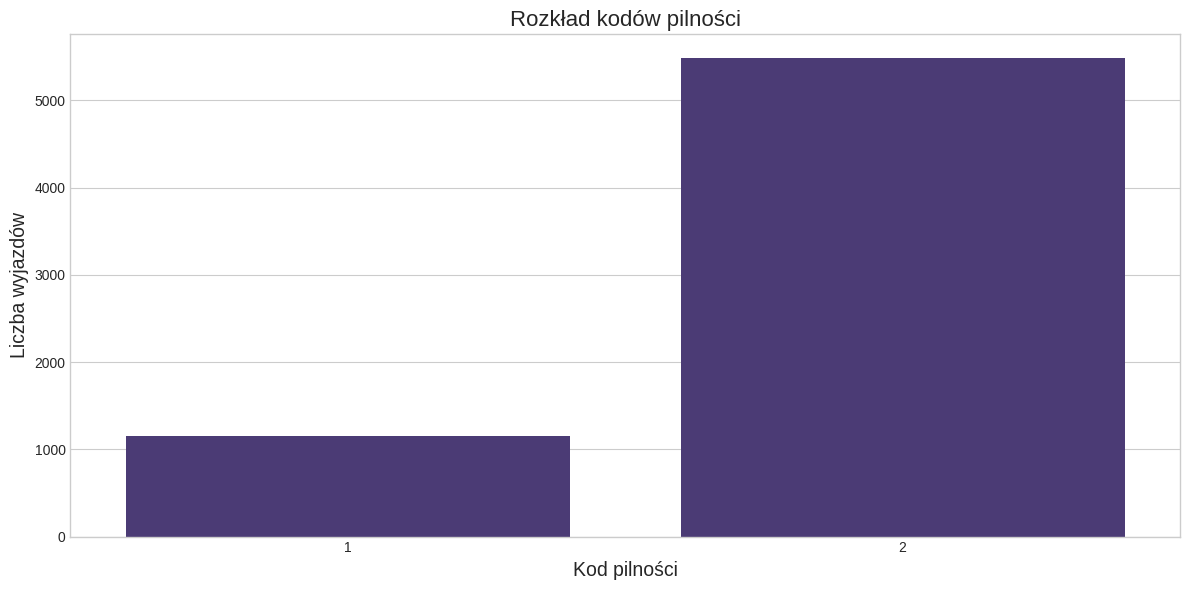

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Kod pilności', data=gdf)
plt.title('Rozkład kodów pilności', fontsize=16)
plt.xlabel('Kod pilności', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.tight_layout()
plt.show()

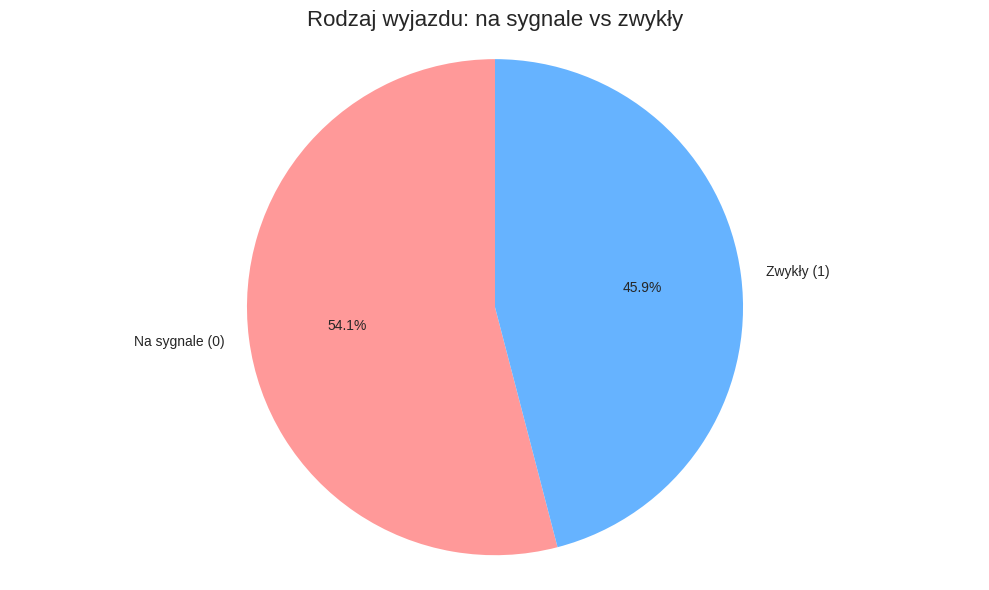

In [8]:
plt.figure(figsize=(10, 6))
trip_type_counts = gdf['Rodzaj wyjazdu'].value_counts()
labels = ['Na sygnale (0)', 'Zwykły (1)']
plt.pie(trip_type_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff'])
plt.axis('equal')
plt.title('Rodzaj wyjazdu: na sygnale vs zwykły', fontsize=16)
plt.tight_layout()
plt.show()

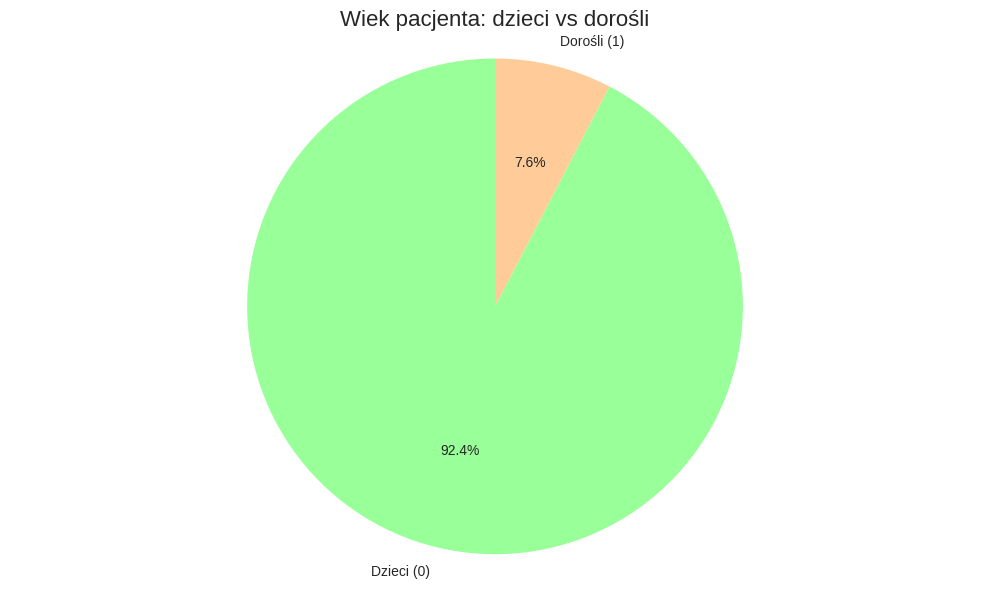

In [9]:
plt.figure(figsize=(10, 6))
age_counts = gdf['Określenie wieku pacjenta'].value_counts()
labels = ['Dzieci (0)', 'Dorośli (1)']
plt.pie(age_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=['#99ff99','#ffcc99'])
plt.axis('equal')
plt.title('Wiek pacjenta: dzieci vs dorośli', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
start_points = gdf.geometry.apply(lambda x: Point(x.coords[0]))
start_points_gdf = gpd.GeoDataFrame(gdf[['wyjazd_id', 'Powód wezwania', 'Kod pilności']], 
                                    geometry=start_points, crs=gdf.crs)

center_lat = start_points_gdf.geometry.y.mean()
center_lon = start_points_gdf.geometry.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

heat_data = [[point.y, point.x] for point in start_points_gdf.geometry]
HeatMap(heat_data).add_to(m)

m.save('heatmap_wyjazdy.html')
print("Zapisano mapę cieplną do pliku heatmap_wyjazdy.html")

Zapisano mapę cieplną do pliku heatmap_wyjazdy.html


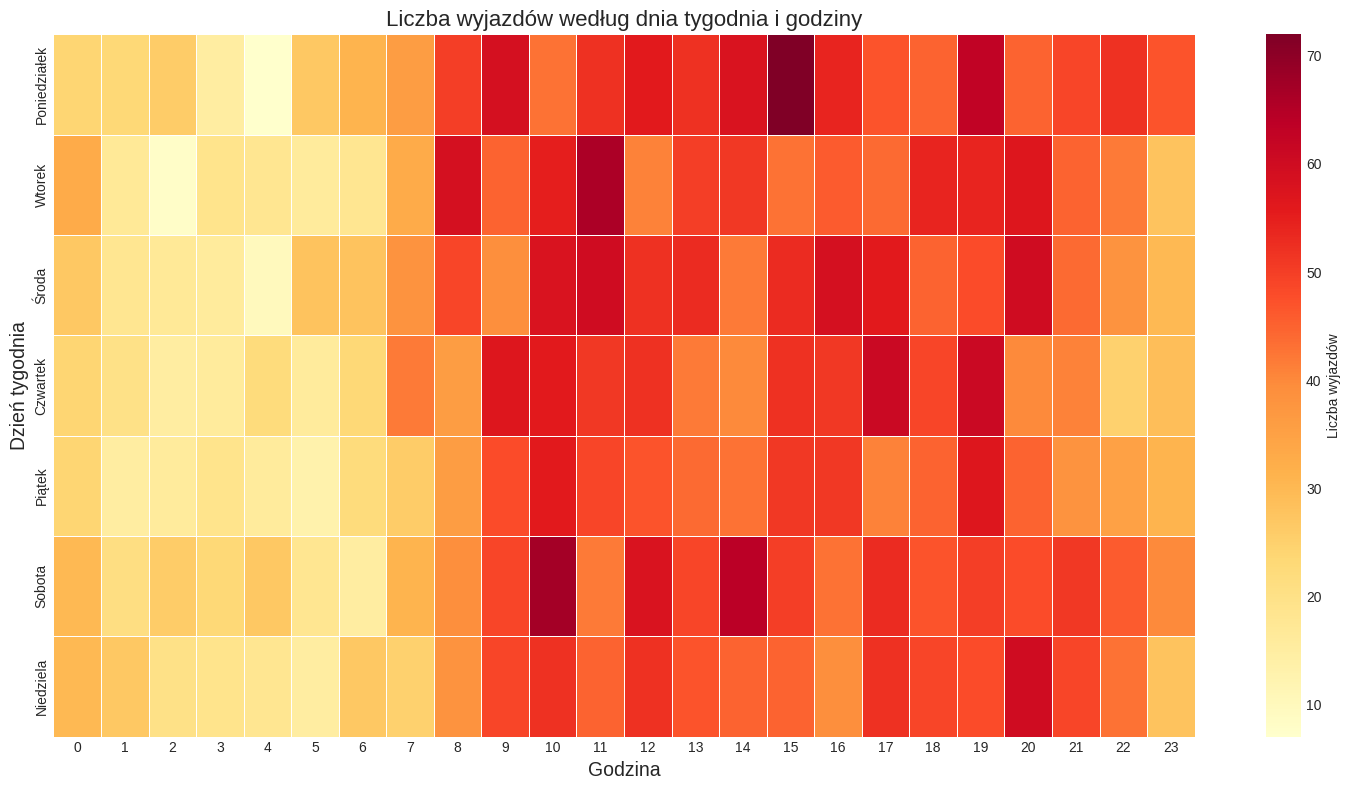

In [11]:
plt.figure(figsize=(15, 8))
hour_day_pivot = pd.crosstab(index=gdf['Dzień tygodnia nazwa'], 
                             columns=gdf['Godzina wyjazdu'])

hour_day_pivot = hour_day_pivot.reindex(['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
                                         'Piątek', 'Sobota', 'Niedziela'])

sns.heatmap(hour_day_pivot, cmap="YlOrRd", linewidths=.5, annot=False, fmt='d', cbar_kws={'label': 'Liczba wyjazdów'})
plt.title('Liczba wyjazdów według dnia tygodnia i godziny', fontsize=16)
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Dzień tygodnia', fontsize=14)
plt.tight_layout()
plt.show()

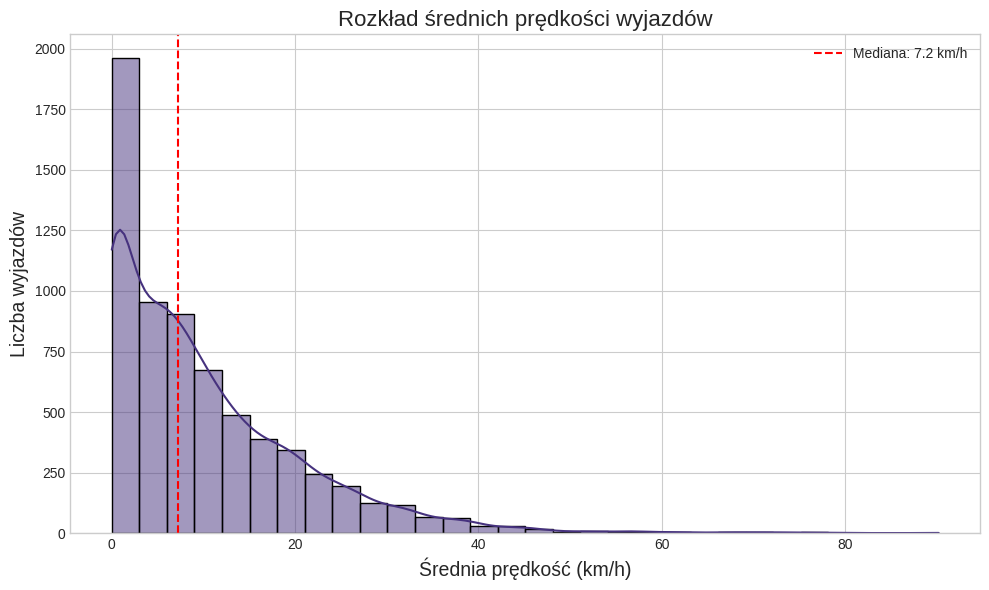

In [12]:
gdf['Średnia prędkość (km/h)'] = gdf['Długość trasy (km)'] / (gdf['Czas trwania (min)']/60)

gdf_speed = gdf[gdf['Średnia prędkość (km/h)'] < 100]

plt.figure(figsize=(10, 6))
sns.histplot(gdf_speed['Średnia prędkość (km/h)'], bins=30, kde=True)
plt.axvline(gdf_speed['Średnia prędkość (km/h)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf_speed["Średnia prędkość (km/h)"].median():.1f} km/h')
plt.title('Rozkład średnich prędkości wyjazdów', fontsize=16)
plt.xlabel('Średnia prędkość (km/h)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

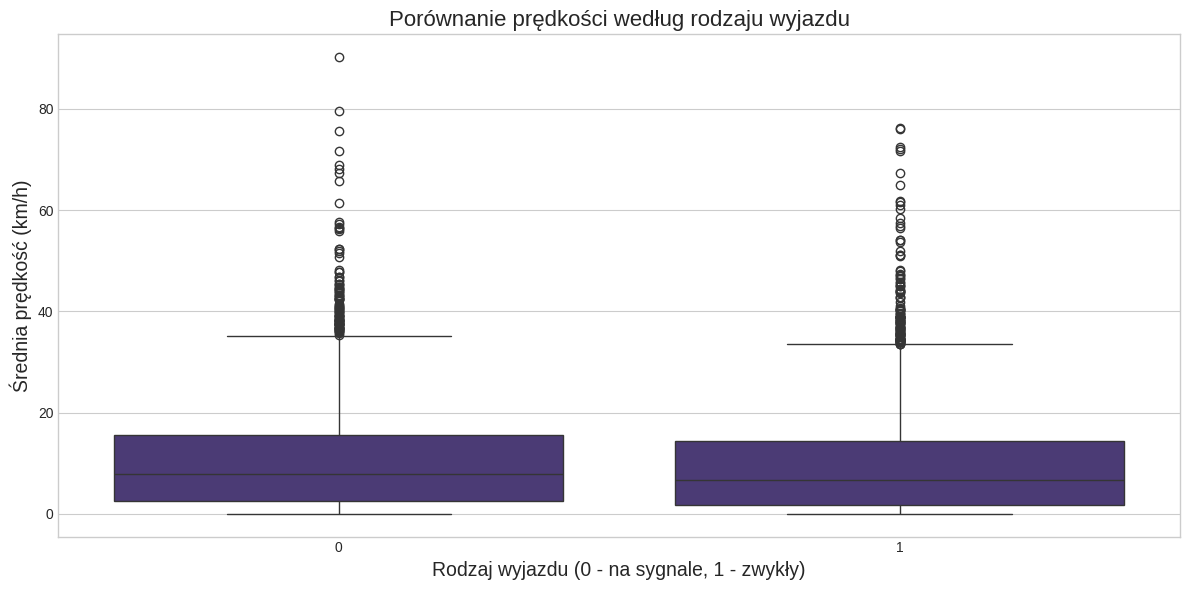

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Rodzaj wyjazdu', y='Średnia prędkość (km/h)', data=gdf_speed)
plt.title('Porównanie prędkości według rodzaju wyjazdu', fontsize=16)
plt.xlabel('Rodzaj wyjazdu (0 - na sygnale, 1 - zwykły)', fontsize=14)
plt.ylabel('Średnia prędkość (km/h)', fontsize=14)
plt.tight_layout()
plt.show()

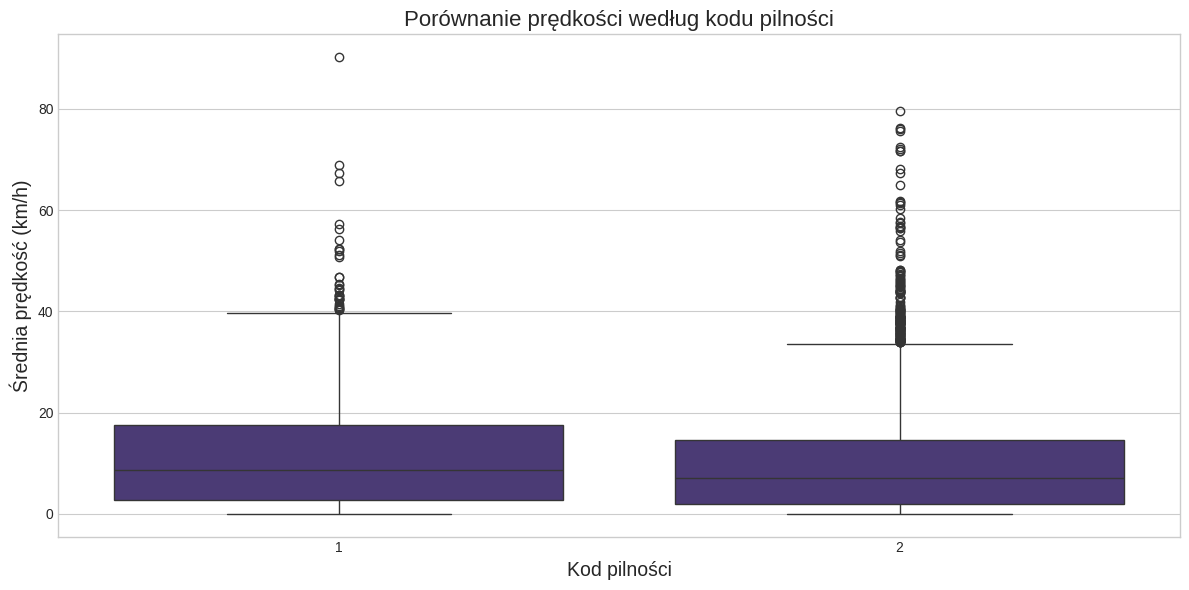

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Kod pilności', y='Średnia prędkość (km/h)', data=gdf_speed)
plt.title('Porównanie prędkości według kodu pilności', fontsize=16)
plt.xlabel('Kod pilności', fontsize=14)
plt.ylabel('Średnia prędkość (km/h)', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
unique_codes = gdf['Kod pilności'].unique()
colormap = dict(zip(unique_codes, plt.cm.tab10(np.linspace(0, 1, len(unique_codes)))))

m2 = folium.Map(location=[center_lat, center_lon], zoom_start=12)

for idx, row in gdf.iterrows():
    if isinstance(row['Kod pilności'], (int, float, str)):
        try:
            code = int(float(row['Kod pilności']))
            coords = [(y, x) for x, y in row['geometry'].coords]
            
            rgba = colormap.get(code, (0, 0, 0, 1))
            hex_color = mcolors.rgb2hex(rgba[:3])
            
            folium.PolyLine(
                coords,
                color=hex_color,
                weight=2,
                opacity=0.7,
                popup=f"ID: {row['wyjazd_id']}<br>Powód: {row['Powód wezwania']}<br>Kod: {code}"
            ).add_to(m2)
        except (ValueError, TypeError):
            continue

for code in unique_codes:
    if isinstance(code, (int, float, str)):
        try:
            code_val = int(float(code))
            rgba = colormap.get(code_val, (0, 0, 0, 1))
            hex_color = mcolors.rgb2hex(rgba[:3])
            legend_html += f'<p><span style="color:{hex_color};">■</span> Kod {code_val}</p>'
        except (ValueError, TypeError):
            continue

legend_html += '</div>'
m2.get_root().html.add_child(folium.Element(legend_html))

m2.save('trasy_wg_kodu_pilnosci.html')
print("Zapisano mapę tras wg kodów pilności do pliku trasy_wg_kodu_pilnosci.html")

NameError: name 'legend_html' is not defined

In [ ]:
plt.figure(figsize=(15, 6))
daily_calls.plot(alpha=0.5, label='Dane dzienne')
daily_calls.rolling(window=7).mean().plot(linewidth=2, label='Średnia 7-dniowa')
plt.title('Trend liczby wyjazdów (średnia krocząca 7-dniowa)', fontsize=16)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()